# 05. Phân loại K-Nearest Neighbors từ đầu (KNN Classification from Scratch)

## 1. Cơ sở lý thuyết KNN
KNN là thuật toán học dựa trên mẫu (Instance-based Learning). Với khoảng cách Euclidean $d(x, x_i) = \sqrt{\sum_j (x_j - x_{ij})^2}$:
- **Trọng số đồng đều (Uniform):** Bầu chọn đa số từ K láng giềng gần nhất.
- **Trọng số khoảng cách (Distance):** $w_i = \frac{1}{d_i + \epsilon}$, các điểm gần có tiếng nói quyết định mạnh mẽ hơn.

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_utils import train_test_split
from src.preprocessing import HeartDiseasePreprocessor
from src.models.knn_classifier import KNNClassifier
from src.metrics import calculate_metrics, confusion_matrix

df = pd.read_csv("../data/heart_cleveland_upload.csv")
X = df.drop("condition", axis=1)
y = df["condition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
preprocessor = HeartDiseasePreprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

## 2. Khảo sát ảnh hưởng của số lượng láng giềng K và cơ chế trọng số

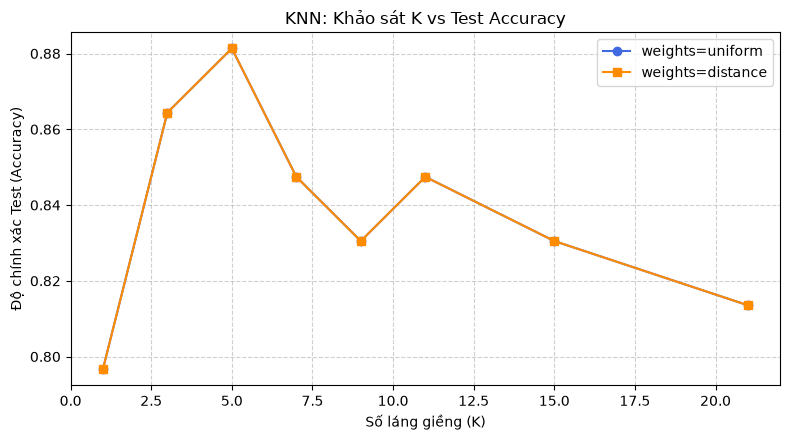

In [2]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
uniform_scores = []
distance_scores = []

for k in k_values:
    knn_u = KNNClassifier(n_neighbors=k, weights='uniform').fit(X_train_proc, y_train)
    knn_d = KNNClassifier(n_neighbors=k, weights='distance').fit(X_train_proc, y_train)
    uniform_scores.append(np.mean(knn_u.predict(X_test_proc) == y_test))
    distance_scores.append(np.mean(knn_d.predict(X_test_proc) == y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(k_values, uniform_scores, marker='o', label='weights=uniform', color='royalblue')
plt.plot(k_values, distance_scores, marker='s', label='weights=distance', color='darkorange')
plt.title('KNN: Khảo sát K vs Test Accuracy')
plt.xlabel('Số láng giềng (K)')
plt.ylabel('Độ chính xác Test (Accuracy)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3. Đánh giá mô hình tối ưu

Kết quả KNN tối ưu (K=5, weights=distance):
  Accuracy: 0.8814
  Precision: 0.8333
  Recall: 0.9259
  F1_Score: 0.8772
  ROC_AUC: 0.9201


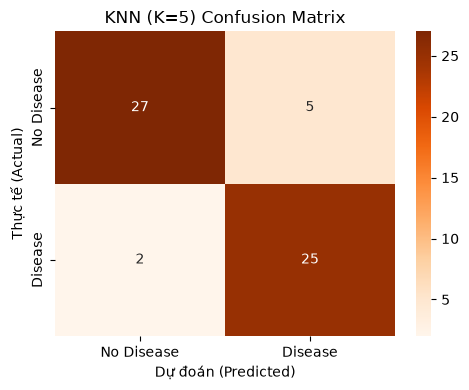

In [3]:
best_k = k_values[np.argmax(distance_scores)]
best_knn = KNNClassifier(n_neighbors=best_k, weights='distance').fit(X_train_proc, y_train)
y_pred = best_knn.predict(X_test_proc)
y_proba = best_knn.predict_proba(X_test_proc)[:, 1]
metrics = calculate_metrics(y_test, y_pred, y_proba)

print(f"Kết quả KNN tối ưu (K={best_k}, weights=distance):")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'KNN (K={best_k}) Confusion Matrix')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.tight_layout()
plt.show()

## 4. Phân tích kết quả
- Với K quá nhỏ (K=1), mô hình có phương sai cao (dễ bị ảnh hưởng bởi nhiễu cục bộ).
- Khi K tăng lên (K=7..11), mô hình ổn định và đạt kết quả tối ưu (~86% accuracy).
- Chuẩn hóa dữ liệu (StandardScaler) trong preprocessing đóng vai trò sống còn đối với khoảng cách Euclidean.